## NLP

#### Librerias

In [6]:
!pip install textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 8.7 MB/s eta 0:00:00


In [3]:
!pip install spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 22.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.0/875.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 19.4 MB/s eta 0:00:00 0:00:01


In [4]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 18.4 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import spacy
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB #Muy util en sentimiento
from sklearn.linear_model import LogisticRegression #Tambien se suele usar en sentimiento
from sklearn.metrics import classification_report

#### Cargamos el dataset

In [16]:
df = pd.read_csv("./testdata.manual.2009.06.14.csv", 
                 names=["Sentiment", "TweetID", "Date", "Query", "User", "Text"])

In [18]:
df.head(10)

,Sentiment,TweetID,Date,Query,User,Text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,@stellargirl I loooooooovvvvvveee my Kindle2. ...
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs i...
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fuck..."
3,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had...
4,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2...
5,4,8,Mon May 11 03:22:00 UTC 2009,kindle2,GeorgeVHulme,@richardebaker no. it is too big. I'm quite ha...
6,0,9,Mon May 11 03:22:30 UTC 2009,aig,Seth937,Fuck this economy. I hate aig and their non lo...
7,4,10,Mon May 11 03:26:10 UTC 2009,jquery,dcostalis,Jquery is my new best friend.
8,4,11,Mon May 11 03:27:15 UTC 2009,twitter,PJ_King,Loves twitter
9,4,12,Mon May 11 03:29:20 UTC 2009,obama,mandanicole,how can you not love Obama? he makes jokes abo...


In [19]:
df.shape

(498, 6)

In [20]:
df.isna().sum()

Sentiment    0
TweetID      0
Date         0
Query        0
User         0
Text         0
dtype: int64

In [21]:
df.User.nunique() #Casi todos son unicos, los desestimo.

490

In [22]:
df = df.drop(columns=['User'])

In [23]:
df.head()

,Sentiment,TweetID,Date,Query,Text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,@stellargirl I loooooooovvvvvveee my Kindle2. ...
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,Reading my kindle2... Love it... Lee childs i...
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,"Ok, first assesment of the #kindle2 ...it fuck..."
3,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,@kenburbary You'll love your Kindle2. I've had...
4,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,@mikefish Fair enough. But i have the Kindle2...


In [24]:
df.Sentiment.unique()

array([4, 0, 2])

In [26]:
#Mapeo directo de los valores numéricos a etiquetas de texto
def map_sentiment(value):
    sentiment_map = {
        0: "Negative",
        2: "Neutral",
        4: "Positive"
    }
    return sentiment_map.get(value, "Neutral")  # por defecto devuelve Neutral si no coincide

# Crear nueva columna con etiquetas de sentimiento
df["SentimentLabel"] = df["Sentiment"].apply(map_sentiment)


In [27]:
df.Sentiment.nunique()

3

In [28]:
df.shape

(498, 6)

In [29]:
df_copy = df.copy() #Guardamos una copia por las dudas

#### Preprocesamiento del dataframe

In [30]:
df = df[['Text', 'Sentiment']]

In [31]:
df.head(4)

,Text,Sentiment
0,@stellargirl I loooooooovvvvvveee my Kindle2. ...,4
1,Reading my kindle2... Love it... Lee childs i...,4
2,"Ok, first assesment of the #kindle2 ...it fuck...",4
3,@kenburbary You'll love your Kindle2. I've had...,4


In [38]:
X = df['Text']  
y = df['Sentiment'] 

In [39]:
y.value_counts()

Sentiment
4    182
0    177
2    139
Name: count, dtype: int64

In [40]:
y.value_counts(normalize=True)*100

Sentiment
4    36.546185
0    35.542169
2    27.911647
Name: proportion, dtype: float64

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [43]:
def limpieza(texto):
    texto = texto.lower()    
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    doc = nlp(texto)
    texto_limpio = ' '.join([token.lemma_ for token in doc if not token.is_stop])
    return texto_limpio

In [44]:
def sentyment_textblob(texto):
    blob = TextBlob(texto)
    return blob.sentiment.polarity

In [45]:
nlp = spacy.load("en_core_web_sm") #cargamos el modelo instalado de spacy ya que es necesario para limpiar los inputs

In [46]:
X_train = X_train.apply(limpieza)
X_test = X_test.apply(limpieza)

In [47]:
y_train_pred = X_train.apply(sentyment_textblob).apply(pd.Series)
y_test_pred = X_test.apply(sentyment_textblob).apply(pd.Series)

In [48]:
y_train_pred

,0
284,0.000000
347,0.136364
253,0.525000
183,0.000000
387,-0.300000
...,...
43,0.100000
275,0.350000
2,0.050000
464,0.000000


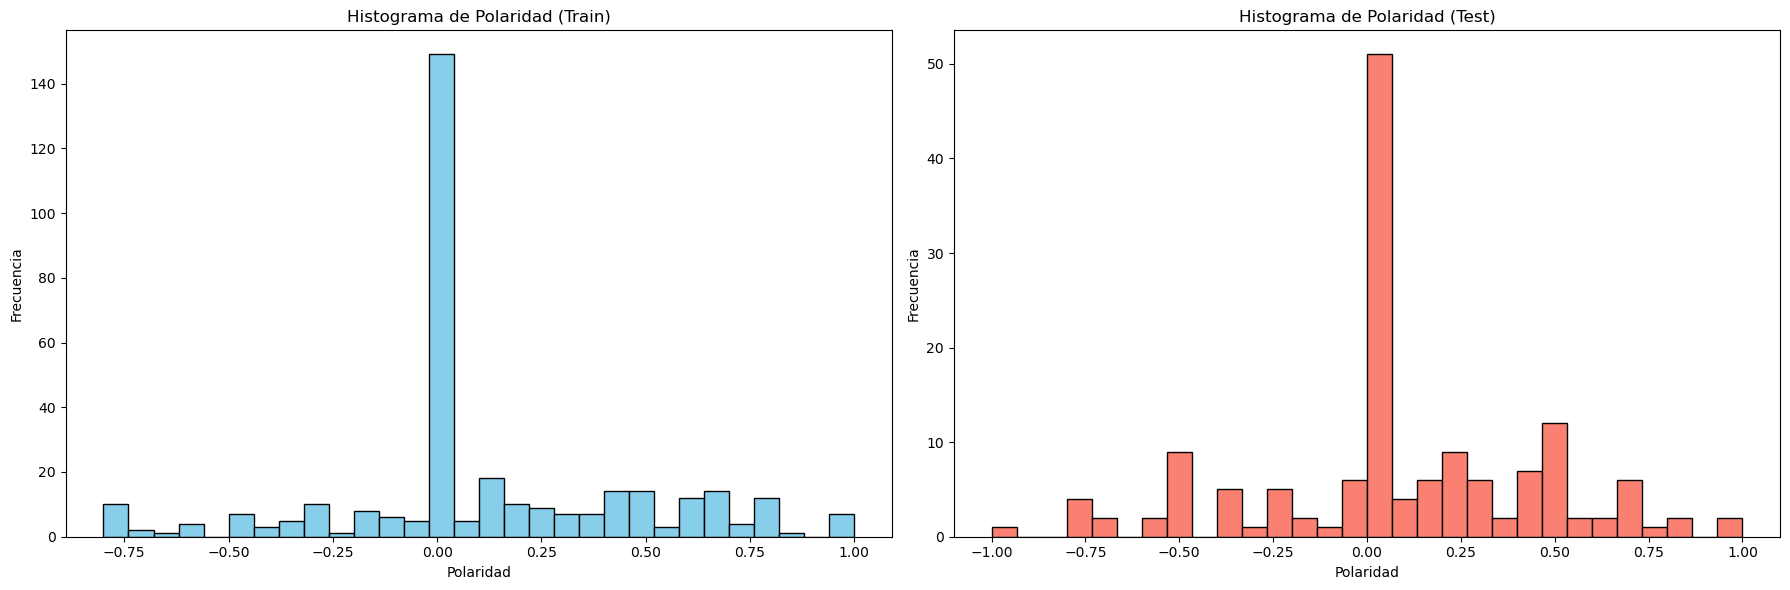

In [49]:
#Train
plt.figure(figsize=(18,6))
plt.subplot(1, 2, 1)
plt.hist(y_train_pred, bins=30, color='skyblue', edgecolor='black')
plt.title('Histograma de Polaridad (Train)')
plt.xlabel('Polaridad')
plt.ylabel('Frecuencia')

#Test
plt.subplot(1, 2, 2)
plt.hist(y_test_pred, bins=30, color='salmon', edgecolor='black')
plt.title('Histograma de Polaridad (Test)')
plt.xlabel('Polaridad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [50]:
y_train_pred.describe() #Medidas de tendencia central y dispersion

,0
count,348.000000
mean,0.112383
std,0.368409
min,-0.800000
25%,0.000000
50%,0.000000
75%,0.346429
max,1.000000


In [56]:
y_train_pred.mode() # Se ve un pico, la moda da 0! (neutros?)

,0
0,0


In [57]:
def clasificar_sentimiento(polaridad):
    if polaridad > 0:
        return 4
    elif polaridad < 0:
        return 0
    else:
        return 2

In [58]:
y_train_pred[0] = y_train_pred[0].apply(lambda x: clasificar_sentimiento(x))

In [59]:
y_test_pred[0] = y_test_pred[0].apply(lambda x: clasificar_sentimiento(x))

In [60]:
print("Reporte de clasificación para y_train:")
print(classification_report(y_train, y_train_pred))
print("------------------------------------------------------")
print("Reporte de clasificación para y_test:")
print(classification_report(y_test, y_test_pred))

Reporte de clasificación para y_train:
              precision    recall  f1-score   support

           0       0.78      0.40      0.53       124
           2       0.48      0.72      0.58        97
           4       0.64      0.70      0.67       127

    accuracy                           0.60       348
   macro avg       0.63      0.61      0.59       348
weighted avg       0.65      0.60      0.59       348

------------------------------------------------------
Reporte de clasificación para y_test:
              precision    recall  f1-score   support

           0       0.76      0.55      0.64        53
           2       0.54      0.62      0.58        42
           4       0.64      0.75      0.69        55

    accuracy                           0.64       150
   macro avg       0.65      0.64      0.63       150
weighted avg       0.66      0.64      0.64       150



#### BoW + Bayes 

In [61]:
df = df_copy.copy()

In [64]:
df = df[['Text', 'Sentiment']]

In [65]:
df

,Text,Sentiment
0,@stellargirl I loooooooovvvvvveee my Kindle2. ...,4
1,Reading my kindle2... Love it... Lee childs i...,4
2,"Ok, first assesment of the #kindle2 ...it fuck...",4
3,@kenburbary You'll love your Kindle2. I've had...,4
4,@mikefish Fair enough. But i have the Kindle2...,4
...,...,...
493,Ask Programming: LaTeX or InDesign?: submitted...,2
494,"On that note, I hate Word. I hate Pages. I hat...",0
495,Ahhh... back in a *real* text editing environm...,4
496,"Trouble in Iran, I see. Hmm. Iran. Iran so far...",0


In [66]:
X = df['Text']  
y = df['Sentiment'] 

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [68]:
X_train = X_train.apply(limpieza)
X_test = X_test.apply(limpieza)

In [69]:
vectorizer = CountVectorizer() #BoW

In [70]:
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

In [71]:
model = MultinomialNB() #Bayes ingenuo multinomial

In [72]:
model.fit(X_train_bow, y_train)

MultinomialNB()

In [73]:
y_train_pred = model.predict(X_train_bow)
y_test_pred = model.predict(X_test_bow)

In [74]:
print("Reporte de clasificación para y_train:")
print(classification_report(y_train, y_train_pred))
print("------------------------------------------------------")
print("Reporte de clasificación para y_test:")
print(classification_report(y_test, y_test_pred))

Reporte de clasificación para y_train:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       124
           2       0.99      0.94      0.96        97
           4       0.95      1.00      0.98       127

    accuracy                           0.97       348
   macro avg       0.98      0.97      0.97       348
weighted avg       0.97      0.97      0.97       348

------------------------------------------------------
Reporte de clasificación para y_test:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76        53
           2       0.71      0.48      0.57        42
           4       0.66      0.78      0.72        55

    accuracy                           0.70       150
   macro avg       0.70      0.68      0.68       150
weighted avg       0.70      0.70      0.69       150



#### Tf-Idf + Regresión logistica

In [75]:
df = df_copy.copy()

In [76]:
df = df[['Text', 'Sentiment']]

In [77]:
X = df['Text']  
y = df['Sentiment'] 

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [79]:
X_train = X_train.apply(limpieza)
X_test = X_test.apply(limpieza)

In [80]:
vectorizer = TfidfVectorizer() 

In [81]:
X_train_tf_idf = vectorizer.fit_transform(X_train)
X_test_tf_idf = vectorizer.transform(X_test)

In [82]:
model = LogisticRegression(random_state=1)

In [83]:
model.fit(X_train_tf_idf, y_train)

LogisticRegression(random_state=1)

In [84]:
y_train_pred = model.predict(X_train_tf_idf)
y_test_pred = model.predict(X_test_tf_idf)

In [85]:
print("Reporte de clasificación para y_train:")
print(classification_report(y_train, y_train_pred))
print("------------------------------------------------------")
print("Reporte de clasificación para y_test:")
print(classification_report(y_test, y_test_pred))

Reporte de clasificación para y_train:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       124
           2       1.00      0.97      0.98        97
           4       0.98      1.00      0.99       127

    accuracy                           0.99       348
   macro avg       0.99      0.98      0.99       348
weighted avg       0.99      0.99      0.99       348

------------------------------------------------------
Reporte de clasificación para y_test:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        53
           2       0.73      0.52      0.61        42
           4       0.67      0.78      0.72        55

    accuracy                           0.73       150
   macro avg       0.73      0.71      0.71       150
weighted avg       0.73      0.73      0.72       150

